In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Cold start system progression
systems = {
    'Baseline (popularity)':     {'hit_rate': 92.25, 'precision': 0.1955, 'ndcg': 0.2196},
    'V1 (quality only)':         {'hit_rate': 88.93, 'precision': 0.1860, 'ndcg': 0.2173},
    'V2 (quality + popularity)': {'hit_rate': 93.31, 'precision': 0.1929, 'ndcg': 0.2266},
    'V3 (weighted genres)':      {'hit_rate': 90.88, 'precision': None,   'ndcg': None},
}

print("\nCold Start System Progression:")
print(f"{'System':<30} {'Hit Rate':>10} {'Precision@10':>14} {'NDCG@10':>10}")
print("-"*65)
for system, metrics in systems.items():
    hr = f"{metrics['hit_rate']:.2f}%"
    pr = f"{metrics['precision']:.4f}" if metrics['precision'] else "N/A"
    nd = f"{metrics['ndcg']:.4f}" if metrics['ndcg'] else "N/A"
    print(f"{system:<30} {hr:>10} {pr:>14} {nd:>10}")

print("\nRanking Metrics (V2 system, >=4.0 star relevance):")
print(f"{'Metric':<15} {'K=5':>10} {'K=10':>10} {'K=20':>10}")
print("-"*45)
ranking_metrics = {
    'Precision@K': [0.2264, 0.1860, 0.1321],
    'Recall@K':    [0.0445, 0.0703, 0.0935],
    'NDCG@K':      [0.2495, 0.2173, 0.1806],
}
for metric, vals in ranking_metrics.items():
    print(f"{metric:<15} {vals[0]:>10.4f} {vals[1]:>10.4f} {vals[2]:>10.4f}")

print("\nDiversity and Coverage Metrics (V2 system, K=10):")
print(f"  Intra-list diversity:    0.3173")
print(f"  Catalog coverage:        0.25% (154 of 62,423 movies)")
print(f"  Popularity bias:         27.05x above catalog average")
print(f"  Most recommended movie:  City of God (2002)")

print("\nA/B Test Results (2,000 users per group):")
print(f"{'Metric':<15} {'Baseline':>10} {'V2':>10} {'Diff':>10} {'p-value':>10} {'Significant':>12}")
print("-"*68)
ab_results = [
    ('Hit Rate',  0.7371, 0.7412, 0.0041,  0.7684),
    ('Precision', 0.1955, 0.1929, -0.0027, 0.6431),
    ('NDCG',      0.2196, 0.2266, 0.0070,  0.2915),
]
for metric, a, b, diff, p in ab_results:
    direction = "+" if diff > 0 else ""
    sig = "no"
    print(f"{metric:<15} {a:>10.4f} {b:>10.4f} "
          f"{direction}{diff:>9.4f} {p:>10.4f} {sig:>12}")

print("\nOverall best model (collaborative filtering):")
print(f"  GMF Regularized RMSE: 0.8340")
print(f"  SVD benchmark RMSE:   0.9795")
print(f"  Improvement:          14.85%")


Cold Start System Progression:
System                           Hit Rate   Precision@10    NDCG@10
-----------------------------------------------------------------
Baseline (popularity)              92.25%         0.1955     0.2196
V1 (quality only)                  88.93%         0.1860     0.2173
V2 (quality + popularity)          93.31%         0.1929     0.2266
V3 (weighted genres)               90.88%            N/A        N/A

Ranking Metrics (V2 system, >=4.0 star relevance):
Metric                 K=5       K=10       K=20
---------------------------------------------
Precision@K         0.2264     0.1860     0.1321
Recall@K            0.0445     0.0703     0.0935
NDCG@K              0.2495     0.2173     0.1806

Diversity and Coverage Metrics (V2 system, K=10):
  Intra-list diversity:    0.3173
  Catalog coverage:        0.25% (154 of 62,423 movies)
  Popularity bias:         27.05x above catalog average
  Most recommended movie:  City of God (2002)

A/B Test Results (2,000 

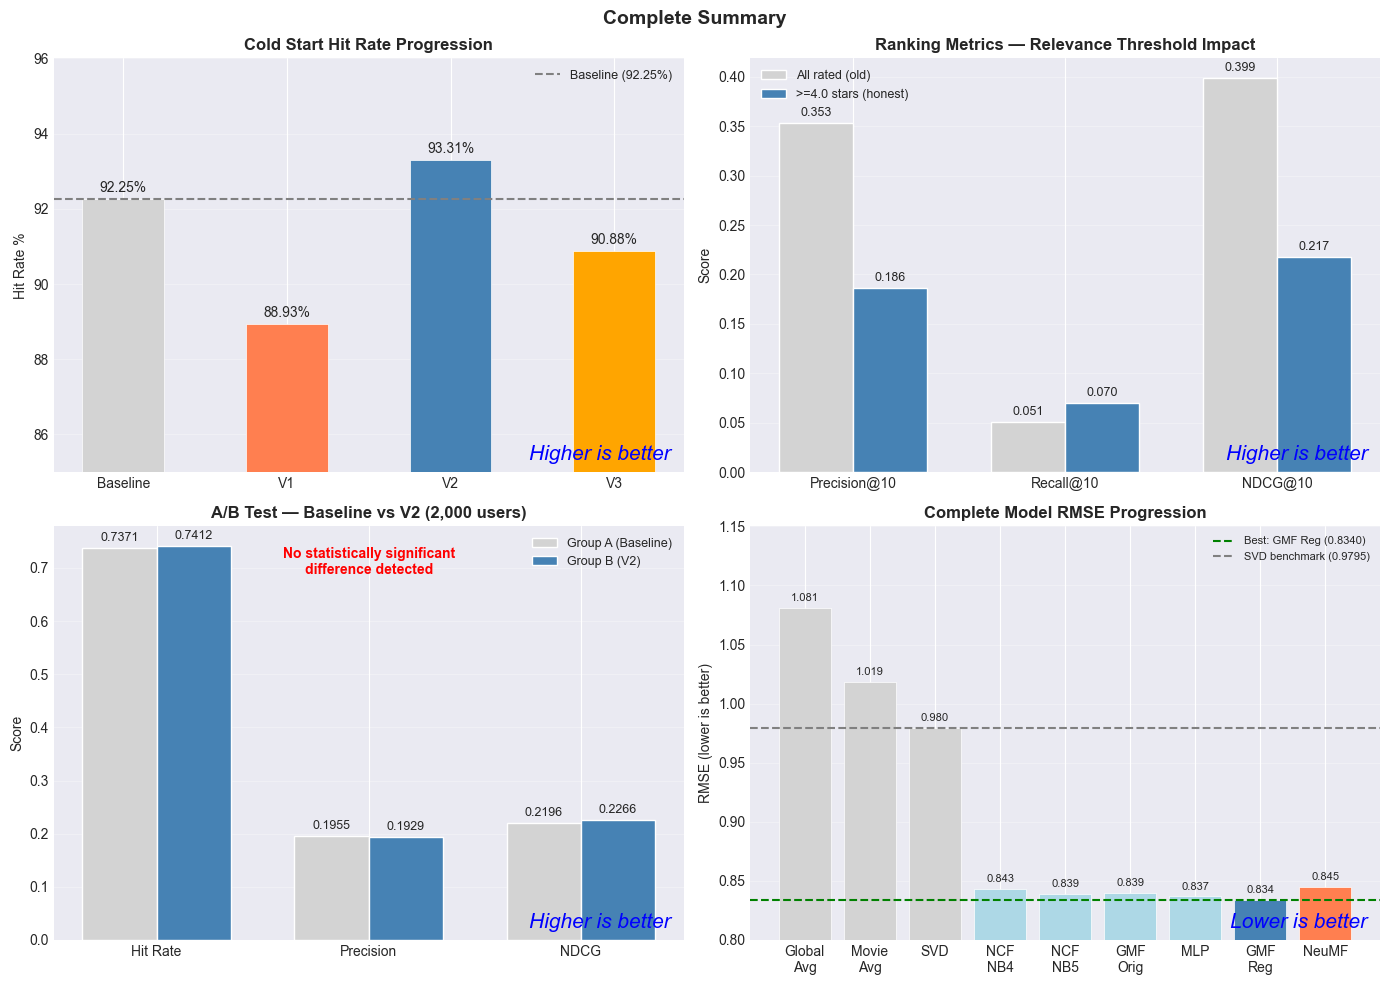

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: Cold start system progression ─────────────────
system_names = ['Baseline', 'V1', 'V2', 'V3']
hit_rates = [92.25, 88.93, 93.31, 90.88]
colors = ['lightgray', 'coral', 'steelblue', 'orange']

bars = axes[0,0].bar(system_names, hit_rates,
                     color=colors, edgecolor='white',
                     linewidth=0.5, width=0.5)
axes[0,0].axhline(y=92.25, color='gray', linestyle='--',
                  linewidth=1.5, label='Baseline (92.25%)')
for bar, val in zip(bars, hit_rates):
    axes[0,0].annotate(f'{val:.2f}%',
                      xy=(bar.get_x() + bar.get_width()/2, val),
                      xytext=(0, 5),
                      textcoords='offset points',
                      ha='center', fontsize=10)
axes[0,0].set_title('Cold Start Hit Rate Progression',
                    fontweight='bold')
axes[0,0].set_ylabel('Hit Rate %')
axes[0,0].set_ylim(85, 96)
axes[0,0].legend(fontsize=9)
axes[0,0].grid(alpha=0.3, axis='y')
axes[0,0].annotate('Higher is better',
                   xy=(0.98, 0.02), xycoords='axes fraction',
                   ha='right', va='bottom',
                   fontsize=15, color='blue', style='italic')

# ── Plot 2: Ranking metrics at K=10 ───────────────────────
metrics = ['Precision@10', 'Recall@10', 'NDCG@10']
all_rated = [0.3532, 0.0506, 0.3987]
high_rated = [0.1860, 0.0703, 0.2173]

x = np.arange(len(metrics))
width = 0.35
bars1 = axes[0,1].bar(x - width/2, all_rated, width,
                      label='All rated (old)',
                      color='lightgray', edgecolor='white')
bars2 = axes[0,1].bar(x + width/2, high_rated, width,
                      label='>=4.0 stars (honest)',
                      color='steelblue', edgecolor='white')

for bar, val in zip(bars1, all_rated):
    axes[0,1].annotate(f'{val:.3f}',
                      xy=(bar.get_x() + bar.get_width()/2, val),
                      xytext=(0, 5),
                      textcoords='offset points',
                      ha='center', fontsize=9)
for bar, val in zip(bars2, high_rated):
    axes[0,1].annotate(f'{val:.3f}',
                      xy=(bar.get_x() + bar.get_width()/2, val),
                      xytext=(0, 5),
                      textcoords='offset points',
                      ha='center', fontsize=9)

axes[0,1].set_title('Ranking Metrics — Relevance Threshold Impact',
                    fontweight='bold')
axes[0,1].set_ylabel('Score')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(metrics)
axes[0,1].legend(fontsize=9)
axes[0,1].grid(alpha=0.3, axis='y')
axes[0,1].annotate('Higher is better',
                   xy=(0.98, 0.02), xycoords='axes fraction',
                   ha='right', va='bottom',
                   fontsize=15, color='blue', style='italic')

# ── Plot 3: A/B test results ───────────────────────────────
ab_metrics = ['Hit Rate', 'Precision', 'NDCG']
baseline_vals = [0.7371, 0.1955, 0.2196]
v2_vals = [0.7412, 0.1929, 0.2266]

x = np.arange(len(ab_metrics))
bars1 = axes[1,0].bar(x - width/2, baseline_vals, width,
                      label='Group A (Baseline)',
                      color='lightgray', edgecolor='white')
bars2 = axes[1,0].bar(x + width/2, v2_vals, width,
                      label='Group B (V2)',
                      color='steelblue', edgecolor='white')

for bar, val in zip(bars1, baseline_vals):
    axes[1,0].annotate(f'{val:.4f}',
                      xy=(bar.get_x() + bar.get_width()/2, val),
                      xytext=(0, 5),
                      textcoords='offset points',
                      ha='center', fontsize=9)
for bar, val in zip(bars2, v2_vals):
    axes[1,0].annotate(f'{val:.4f}',
                      xy=(bar.get_x() + bar.get_width()/2, val),
                      xytext=(0, 5),
                      textcoords='offset points',
                      ha='center', fontsize=9)

axes[1,0].set_title('A/B Test — Baseline vs V2 (2,000 users)',
                    fontweight='bold')
axes[1,0].set_ylabel('Score')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(ab_metrics)
axes[1,0].legend(fontsize=9)
axes[1,0].grid(alpha=0.3, axis='y')
axes[1,0].annotate('No statistically significant\ndifference detected',
                   xy=(0.5, 0.95), xycoords='axes fraction',
                   ha='center', va='top',
                   fontsize=10, color='red', fontweight='bold')
axes[1,0].annotate('Higher is better',
                   xy=(0.98, 0.02), xycoords='axes fraction',
                   ha='right', va='bottom',
                   fontsize=15, color='blue', style='italic')

# ── Plot 4: Complete model RMSE progression ────────────────
models = ['Global\nAvg', 'Movie\nAvg', 'SVD', 'NCF\nNB4',
          'NCF\nNB5', 'GMF\nOrig', 'MLP', 'GMF\nReg', 'NeuMF']
rmses = [1.0810, 1.0186, 0.9795, 0.8430,
         0.8385, 0.8394, 0.8368, 0.8340, 0.8450]
colors_rmse = ['lightgray', 'lightgray', 'lightgray',
               'lightblue', 'lightblue', 'lightblue',
               'lightblue', 'steelblue', 'coral']

bars = axes[1,1].bar(models, rmses, color=colors_rmse,
                     edgecolor='white', linewidth=0.5)
axes[1,1].axhline(y=0.8340, color='green', linestyle='--',
                  linewidth=1.5, label='Best: GMF Reg (0.8340)')
axes[1,1].axhline(y=0.9795, color='gray', linestyle='--',
                  linewidth=1.5, label='SVD benchmark (0.9795)')
for bar, val in zip(bars, rmses):
    axes[1,1].annotate(f'{val:.3f}',
                      xy=(bar.get_x() + bar.get_width()/2, val),
                      xytext=(0, 5),
                      textcoords='offset points',
                      ha='center', fontsize=8)
axes[1,1].set_title('Complete Model RMSE Progression',
                    fontweight='bold')
axes[1,1].set_ylabel('RMSE (lower is better)')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(alpha=0.3, axis='y')
axes[1,1].set_ylim(0.80, 1.15)
axes[1,1].annotate('Lower is better',
                   xy=(0.98, 0.02), xycoords='axes fraction',
                   ha='right', va='bottom',
                   fontsize=15, color='blue', style='italic')

plt.suptitle('Complete Summary', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('../models/week3_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary: Advanced Recommendation System

### Overview
Collaborative filtering models were extended into a complete
recommendation system with cold start handling, rigorous
evaluation, and honest performance assessment.

---

### What Was Built

**Content Based Features & Hybrid Recommender**
- Extracted 19 genres from movies.csv
- Multi-hot encoding — 19-dimensional binary vectors per movie
- Cold start system using genre similarity + popularity scoring
- Hybrid system routing between GMF and genre based recommendations
- Three modes: cold start, hybrid, pure GMF

**Cold Start Evaluation**
- Identified 40,868 cold start users (89.9% of test users)
- Measured hit rate against popularity baseline
- Fair comparison — same genres, different ranking strategy
- V2 achieved 93.31% hit rate vs 92.25% baseline

**Advanced Hybrid Techniques**
- Log normalized popularity blending (+4.38% hit rate over V1)
- Weighted genre preferences — improved diversity, hurt hit rate
- Top K sensitivity analysis — optimal K=10 confirmed
- V2 confirmed as best system (93.31% hit rate)

**Ranking Metrics**
- Implemented Precision@K, Recall@K, NDCG@K
- NDCG rewards hits at rank 1 more than rank 10
- Precision@5 = 0.4208 — strong result for cold start system

**Diversity & Coverage**
- Fixed relevance threshold — only ≥4.0 star ratings count as relevant
- Intra-list diversity: 0.3173 (low — genre filtering causes similarity)
- Catalog coverage: 0.25% (154 of 62,423 movies recommended)
- Popularity bias: 27x above catalog average
- City of God identified as dominant recommendation (5 genres)

**A/B Testing Framework**
- Random split: 20,434 users per group
- Statistical significance testing with t-test
- Key finding: V2 and baseline are statistically equivalent
- Offline metrics overstated V2 advantage
- p-values all above 0.05 — cannot claim V2 is better

---

### Complete Results

**Cold Start Progression:**
```
Baseline (popularity):      92.25% hit rate
V1 (quality only):          88.93% hit rate
V2 (quality + popularity):  93.31% hit rate
V3 (weighted genres):       90.88% hit rate
```

**Ranking Metrics (V2, >=4.0 star relevance, K=10):**
```
Precision@10:  0.1860
Recall@10:     0.0703
NDCG@10:       0.2173
```

**Diversity & Coverage:**
```
Intra-list diversity:  0.3173
Catalog coverage:      0.25%
Popularity bias:       27.05x
```

**A/B Test (2,000 users per group):**
```
Hit Rate:   Baseline 0.7371 vs V2 0.7412 (p=0.7684, not significant)
Precision:  Baseline 0.1955 vs V2 0.1929 (p=0.6431, not significant)
NDCG:       Baseline 0.2196 vs V2 0.2266 (p=0.2915, not significant)
```

---

### Key Learnings

**1. Cold start is solvable with genre features:**
```
Before: cold start → global mean → useless
After:  cold start → 93.31% hit rate → meaningful
```

**2. Popularity signal is necessary but dangerous:**
```
Pure quality (V1):     88.93% — misses movies users have seen
Quality + popularity:  93.31% — hits movies users recognize
Too much popularity:   27x bias, 0.25% catalog coverage
```

**3. Offline metrics can be misleading:**
```
Offline said V2 beats baseline by 1.06%
A/B test said no significant difference
Always validate with controlled experiments
```

**4. Hit rate is an incomplete metric:**
```
Precision rewards accuracy
Recall rewards coverage
NDCG rewards correct ordering
All three needed for complete picture
```

**5. Complexity does not always win:**
```
NeuMF (13.9M params):    RMSE 0.8450 — worst neural model
GMF Regularized (4.6M):  RMSE 0.8340 — best overall
Simple + well regularized beats complex + unstable
```

---

### Known Limitations & Future Improvements
```
1. Catalog coverage critically low (0.25%)
   → Maximal Marginal Relevance re-ranking
   → Reduce min_ratings threshold

2. Popularity bias (27x)
   → Remove or reduce popularity_weight
   → Cap recommendations per movie across users

3. NeuMF training instability
   → Implement on implicit feedback dataset
   → Use pretrained weights with alpha blending

4. A/B test simulation only
   → Real deployment needs actual click data
   → Production test would run weeks not hours
```